## Support Vector Machines (SVMs)

**Support Vector Machines (SVMs)** are a powerful set of supervised learning models used for classification and regression tasks. They are particularly effective in high-dimensional spaces and cases where the number of dimensions is greater than the number of samples.

### Core Idea
The main goal of an SVM is to find a hyperplane in an N-dimensional space (N being the number of features) that distinctly classifies the data points. The best hyperplane is one that has the largest margin between the two classes. Maximizing the margin provides some reinforcement so that future data points can be classified with more confidence.

### Key Concepts
1.  **Hyperplane**: A decision boundary that separates data points of different classes. In 2D, it's a line; in 3D, it's a plane; and in higher dimensions, it's a hyperplane.
2.  **Margin**: The distance between the hyperplane and the nearest data point from either class. These nearest data points are called **support vectors**.
3.  **Support Vectors**: Data points that are closest to the hyperplane. They are critical in defining the orientation and position of the hyperplane.
4.  **Kernel Trick**: For non-linearly separable data, SVMs use a technique called the kernel trick. It implicitly maps the input data into a higher-dimensional feature space where a linear separation is possible.


### Types of SVMs

SVMs can be broadly categorized based on their approach to separating data:

1.  **Linear SVM**: Used for linearly separable data. The model finds a straight line (or hyperplane) that best separates the two classes with the maximum margin.

2.  **Non-linear SVM**: Used when data is not linearly separable in its original feature space. It employs the **kernel trick** to transform the data into a higher-dimensional space where a linear separation might be possible. Common kernel functions include:
    *   **Polynomial Kernel**: $K(x, x') = (γx^T x' + r)^d$
    *   **Radial Basis Function (RBF) / Gaussian Kernel**: $K(x, x') = e^{(-γ||x - x'||^2)}$
    *   **Sigmoid Kernel**: $K(x, x') = \tanh(γx^T x' + r)$

SVMs can also be used for different types of tasks:

*   **Support Vector Classifier (SVC)**: Used for classification problems. This is the most common application of SVMs.
*   **Support Vector Regressor (SVR)**: Used for regression problems. Instead of trying to fit the best hyperplane, SVR tries to fit the best tube (or margin) around the regression line, aiming to keep as many data points as possible within that tube, while minimizing errors outside the tube.


---

## Python Implementation Examples

We will use `scikit-learn` to demonstrate SVC and SVR.

In [98]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm, datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, mean_squared_error


### Example 1: Support Vector Classifier (SVC) for Classification

Let's use the Iris dataset for a classification example.

--- Linear SVC Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.54      0.54      0.54        13
           2       0.54      0.54      0.54        13

    accuracy                           0.73        45
   macro avg       0.69      0.69      0.69        45
weighted avg       0.73      0.73      0.73        45



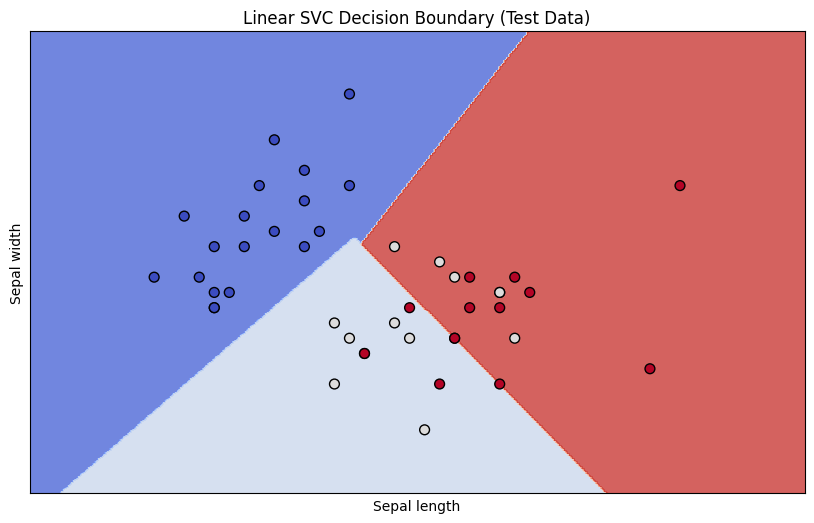


--- RBF Kernel SVC Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.54      0.54      0.54        13
           2       0.54      0.54      0.54        13

    accuracy                           0.73        45
   macro avg       0.69      0.69      0.69        45
weighted avg       0.73      0.73      0.73        45



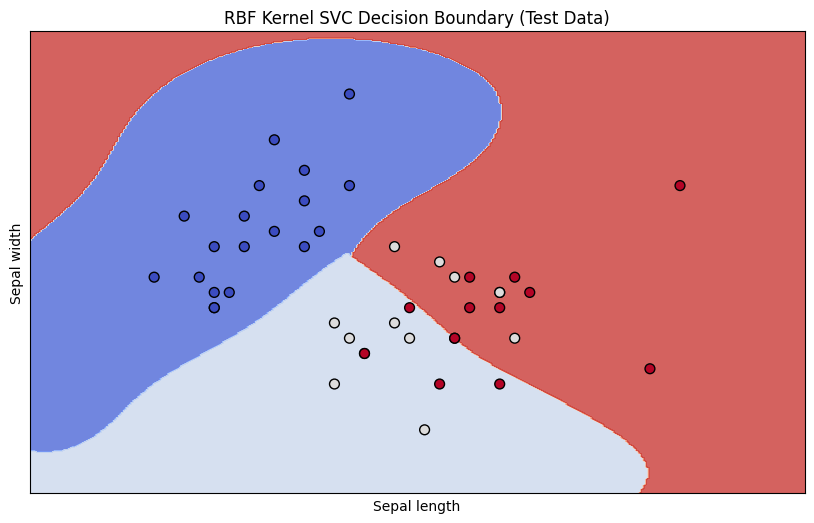

In [99]:
# Load the Iris dataset
iris = datasets.load_iris()
X = iris.data[:, :2]  # We take the first two features for visualization
y = iris.target

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardize features (important for SVMs)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initialize and train a Linear SVC model
svc_linear = svm.SVC(kernel='linear', C=1.0) # C is the regularization parameter
svc_linear.fit(X_train, y_train)

# Make predictions
y_pred_linear = svc_linear.predict(X_test)

# Evaluate the model
print("--- Linear SVC Classification Report ---")
print(classification_report(y_test, y_pred_linear))

# Visualize the decision boundary for Linear SVC
def plot_svc_decision_boundary(X, y, model, title):
    plt.figure(figsize=(10, 6))
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, s=50, edgecolors='k')
    plt.xlabel('Sepal length')
    plt.ylabel('Sepal width')
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.xticks(())
    plt.yticks(())
    plt.title(title)
    plt.show()

plot_svc_decision_boundary(X_test, y_test, svc_linear, 'Linear SVC Decision Boundary (Test Data)')

# Initialize and train a RBF Kernel SVC model (Non-linear)
svc_rbf = svm.SVC(kernel='rbf', gamma=0.7, C=1.0) # gamma is kernel coefficient
svc_rbf.fit(X_train, y_train)

y_pred_rbf = svc_rbf.predict(X_test)

print("\n--- RBF Kernel SVC Classification Report ---")
print(classification_report(y_test, y_pred_rbf))

plot_svc_decision_boundary(X_test, y_test, svc_rbf, 'RBF Kernel SVC Decision Boundary (Test Data)')


### Example 2: Support Vector Regressor (SVR) for Regression

Let's generate some synthetic data for a regression example.

--- SVR Mean Squared Error ---
Mean Squared Error: 0.12


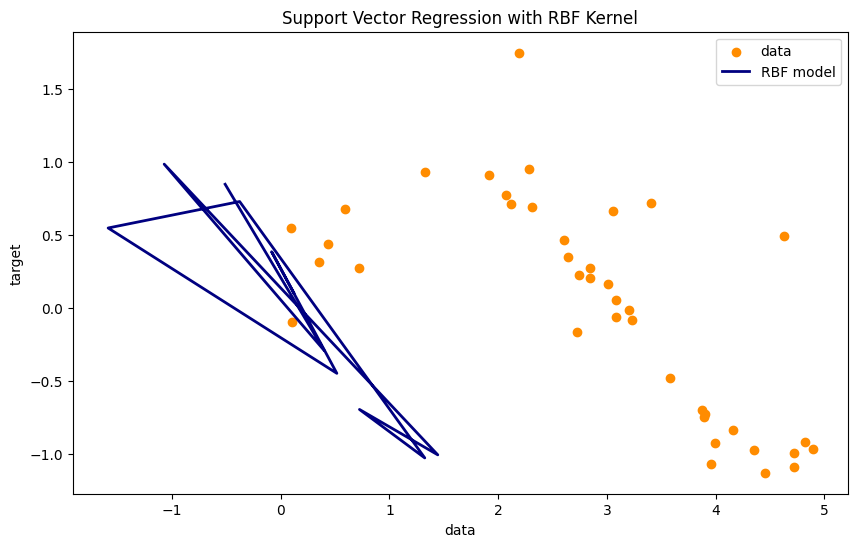

In [100]:
# Generate synthetic data
np.random.seed(0)
X_reg = np.sort(5 * np.random.rand(40, 1), axis=0)
y_reg = np.sin(X_reg).ravel() + np.random.normal(0, 0.1, X_reg.shape[0])

# Add some noise to the data
y_reg[::5] += 3 * (0.5 - np.random.rand(8))

# Split data
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)

# Standardize features
scaler_reg = StandardScaler()
X_train_reg = scaler_reg.fit_transform(X_train_reg)
X_test_reg = scaler_reg.transform(X_test_reg)

# Initialize and train an SVR model (with RBF kernel)
svr_rbf = svm.SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)
svr_rbf.fit(X_train_reg, y_train_reg)

# Make predictions
y_pred_reg = svr_rbf.predict(X_test_reg)

# Evaluate the model
print("--- SVR Mean Squared Error ---")
print(f"Mean Squared Error: {mean_squared_error(y_test_reg, y_pred_reg):.2f}")

# Visualize the SVR predictions
plt.figure(figsize=(10, 6))
plt.scatter(X_reg, y_reg, color='darkorange', label='data')
plt.plot(X_test_reg, y_pred_reg, color='navy', lw=2, label='RBF model')
plt.xlabel('data')
plt.ylabel('target')
plt.title('Support Vector Regression with RBF Kernel')
plt.legend()
plt.show()


### Conclusion

SVMs are versatile models capable of handling both linear and non-linear data for classification and regression tasks. Their strength lies in their ability to work well with high-dimensional data and their use of the kernel trick to solve complex problems. However, they can be computationally intensive on large datasets and sensitive to the choice of kernel and regularization parameters.

# SVM Classifications Programs

# Program 1. Iris Flower Classification

In [101]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report


In [102]:
iris=load_iris()
X=iris.data
y=iris.target

In [103]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [104]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [105]:
model=SVC(kernel='linear',C=1.0)
model.fit(X_train_scaled,y_train)

SVC(kernel='linear')

In [106]:
y_pred=model.predict(X_test_scaled)

In [107]:
print("Accuracy:",accuracy_score(y_test,y_pred))
print("\nClassification Report:\n",classification_report(y_test,y_pred))

Accuracy: 0.9666666666666667

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.89      0.94         9
           2       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30



# Program 2 Wine Classification

In [108]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix


In [109]:
wine=load_wine()

In [110]:
X=wine.data
y=wine.target

In [111]:
X_train,X_test,y_train,y_test=train_test_split(
X,y,test_size=0.25,random_state=10)


In [112]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [113]:
model=SVC(kernel='linear',C=1.0)
model.fit(X_train_scaled,y_train)

SVC(kernel='linear')

In [114]:
predictions=model.predict(X_test_scaled)
print(confusion_matrix(y_test,predictions))

[[13  0  0]
 [ 1 18  4]
 [ 0  0  9]]


# Program 3. Fake News Classification (TF-IDF + SVM)

In [115]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split

In [116]:
texts=[
"Government launches new scheme",
"Win money instantly click here",
"Breaking news election results",
"Cheap loans available now"
]

labels=[1,0,1,0]

In [117]:
X_train,X_test,y_train,y_test=train_test_split(
texts,labels,test_size=0.25)

In [118]:
vectorizer=TfidfVectorizer()

X_train=vectorizer.fit_transform(X_train)
X_test=vectorizer.transform(X_test)


In [119]:
model=LinearSVC()

model.fit(X_train,y_train)

print(model.score(X_test,y_test))

0.0


In [120]:
new_text = ["Government announces new education policy"]

new_text_vector = vectorizer.transform(new_text)

prediction = model.predict(new_text_vector)

print(prediction)

[1]


In [121]:
new_texts = [
    "Government launches healthcare scheme",
    "Congratulations! You won 10 lakh rupees",
    "Election results announced today",
    "Click here to claim your prize"
]

new_vectors = vectorizer.transform(new_texts)

predictions = model.predict(new_vectors)

for text, pred in zip(new_texts, predictions):
    print(text, "->", "Real" if pred == 1 else "Fake")

Government launches healthcare scheme -> Real
Congratulations! You won 10 lakh rupees -> Fake
Election results announced today -> Fake
Click here to claim your prize -> Fake


# Program 4 Demonstrate SVM Hyperplane with 2D Data

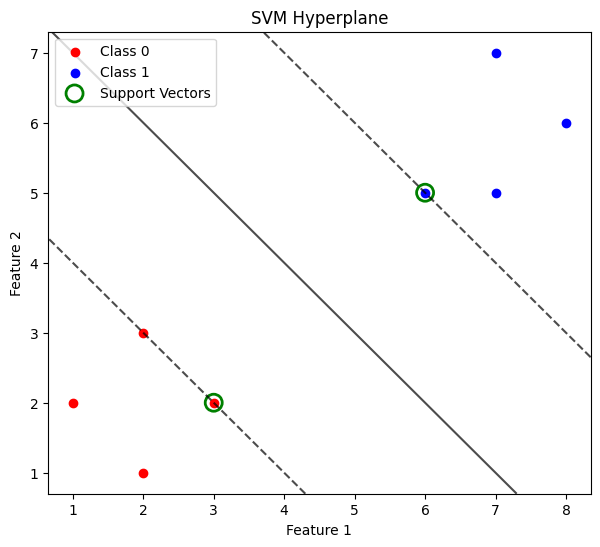

In [122]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# Two features
X = np.array([
    [1,2],
    [2,3],
    [2,1],
    [3,2],
    [6,5],
    [7,7],
    [8,6],
    [7,5]
])

# Labels
y = np.array([0,0,0,0,1,1,1,1])

# Train SVM
model = SVC(kernel="linear")
model.fit(X,y)

# Plot points
plt.figure(figsize=(7,6))

plt.scatter(X[y==0,0], X[y==0,1], color="red", label="Class 0")
plt.scatter(X[y==1,0], X[y==1,1], color="blue", label="Class 1")

# Decision boundary
ax = plt.gca()

xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)

YY, XX = np.meshgrid(yy, xx)

xy = np.vstack([XX.ravel(), YY.ravel()]).T

Z = model.decision_function(xy).reshape(XX.shape)

# Hyperplane and margins
ax.contour(
    XX,
    YY,
    Z,
    colors="k",
    levels=[-1,0,1],
    alpha=0.7,
    linestyles=["--","-","--"]
)

# Support vectors
ax.scatter(
    model.support_vectors_[:,0],
    model.support_vectors_[:,1],
    s=150,
    facecolors="none",
    edgecolors="green",
    linewidth=2,
    label="Support Vectors"
)

plt.legend()
plt.title("SVM Hyperplane")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# Support Vector Regression (SVR).

In [123]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

In [124]:
X = np.array([[1],[2],[3],[4],[5],[6],[7],[8],[9],[10]])
y = np.array([25,30,35,40,50,60,65,70,80,90])


In [125]:
sc_X=StandardScaler()
sc_y=StandardScaler()

X_scaled=sc_X.fit_transform(X)
y_scaled=sc_y.fit_transform(y.reshape(-1,1)).ravel()

In [126]:
model=SVR(kernel="linear")
model.fit(X_scaled,y_scaled)

SVR(kernel='linear')

In [127]:

# Prediction
X_grid = np.linspace(1,10,100).reshape(-1,1)
X_grid_scaled = sc_X.transform(X_grid)

y_pred = model.predict(X_grid_scaled)
y_pred = sc_y.inverse_transform(y_pred.reshape(-1,1))

**Predict a Single New Value**

In [128]:
# Predict salary for 11 years experience
new_exp = np.array([[11]])

# Scale input
new_exp_scaled = sc_X.transform(new_exp)

# Predict (scaled)
pred_scaled = model.predict(new_exp_scaled)

# Convert back to original salary scale
pred_salary = sc_y.inverse_transform(pred_scaled.reshape(-1,1))

print(f"Predicted Salary for {new_exp[0][0]} years = {pred_salary[0][0]:.2f}")

Predicted Salary for 11 years = 93.17


**Predict Multiple New Values**

In [129]:
# New experience values
new_exp = np.array([[11],[12],[13],[15],[18],[20]])

# Scale
new_exp_scaled = sc_X.transform(new_exp)

# Predict
pred_scaled = model.predict(new_exp_scaled)

# Convert back
pred_salary = sc_y.inverse_transform(pred_scaled.reshape(-1,1))

# Print predictions
for exp, salary in zip(new_exp, pred_salary):
    print(f"Experience: {exp[0]} years --> Predicted Salary: {salary[0]:.2f}")

Experience: 11 years --> Predicted Salary: 93.17
Experience: 12 years --> Predicted Salary: 100.20
Experience: 13 years --> Predicted Salary: 107.22
Experience: 15 years --> Predicted Salary: 121.27
Experience: 18 years --> Predicted Salary: 142.35
Experience: 20 years --> Predicted Salary: 156.40


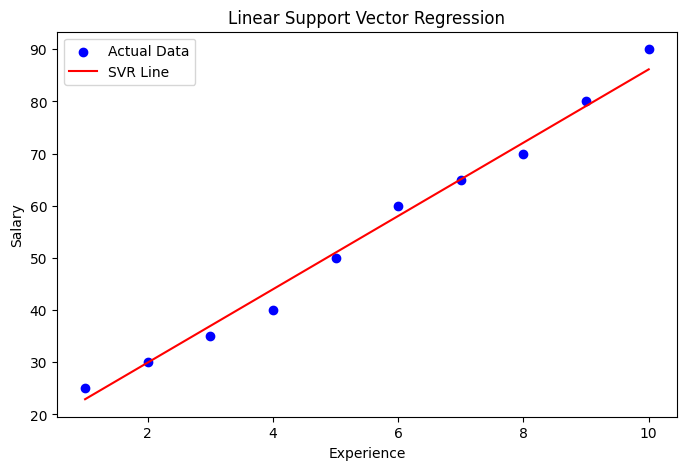

In [130]:
# Visualization
plt.figure(figsize=(8,5))
plt.scatter(X,y,color="blue",label="Actual Data")
plt.plot(X_grid,y_pred,color="red",label="SVR Line")
plt.title("Linear Support Vector Regression")
plt.xlabel("Experience")
plt.ylabel("Salary")
plt.legend()
plt.show()

# Program 2: Non-Linear SVR (RBF Kernel)

In [131]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

# Dataset
X=np.array([[1],[2],[3],[4],[5],[6],[7],[8],[9],[10]])
y=np.array([5,7,12,20,35,55,80,120,170,230])


In [132]:

sc_X=StandardScaler()
sc_y=StandardScaler()


In [133]:
X_scaled=sc_X.fit_transform(X)
y_scaled=sc_y.fit_transform(y.reshape(-1,1)).ravel()

model=SVR(kernel="rbf",C=100,gamma=0.1)

In [134]:
model.fit(X_scaled,y_scaled)

X_grid=np.linspace(1,10,300).reshape(-1,1)


In [135]:

prediction=model.predict(sc_X.transform(X_grid))
prediction=sc_y.inverse_transform(prediction.reshape(-1,1))

In [136]:
# Predict for X = 11

new_x = np.array([[11]])

# Scale input
new_x_scaled = sc_X.transform(new_x)

# Predict
pred_scaled = model.predict(new_x_scaled)

# Convert back to original scale
pred = sc_y.inverse_transform(pred_scaled.reshape(-1,1))

print(f"Prediction for X = {new_x[0][0]} : {pred[0][0]:.2f}")

Prediction for X = 11 : 270.53


In [137]:
new_x = np.array([[11],
                  [12],
                  [13],
                  [15],
                  [18],
                  [20]])

# Scale
new_x_scaled = sc_X.transform(new_x)

# Predict
pred_scaled = model.predict(new_x_scaled)

# Convert back
pred = sc_y.inverse_transform(pred_scaled.reshape(-1,1))

# Display results
for x, y in zip(new_x, pred):
    print(f"Input = {x[0]:2d}  --> Prediction = {y[0]:.2f}")

Input = 11  --> Prediction = 270.53
Input = 12  --> Prediction = 313.92
Input = 13  --> Prediction = 349.87
Input = 15  --> Prediction = 391.77
Input = 18  --> Prediction = 378.15
Input = 20  --> Prediction = 336.14


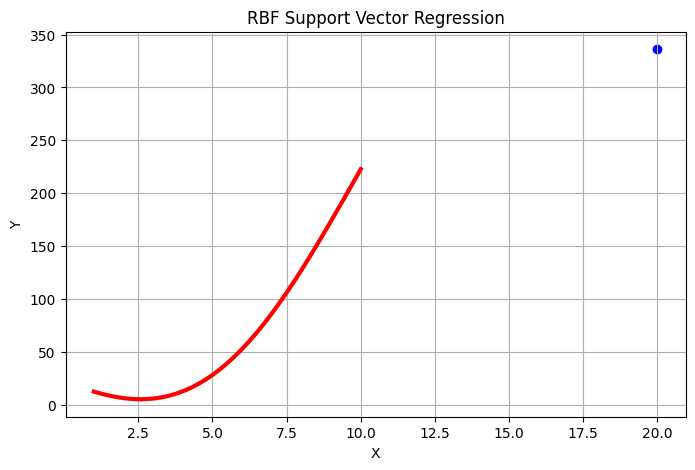

In [139]:
plt.figure(figsize=(8,5))
plt.scatter(x,y,color="blue")
plt.plot(X_grid,prediction,color="red",linewidth=3)
plt.title("RBF Support Vector Regression")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.show()

# Program 3: Polynomial SVR

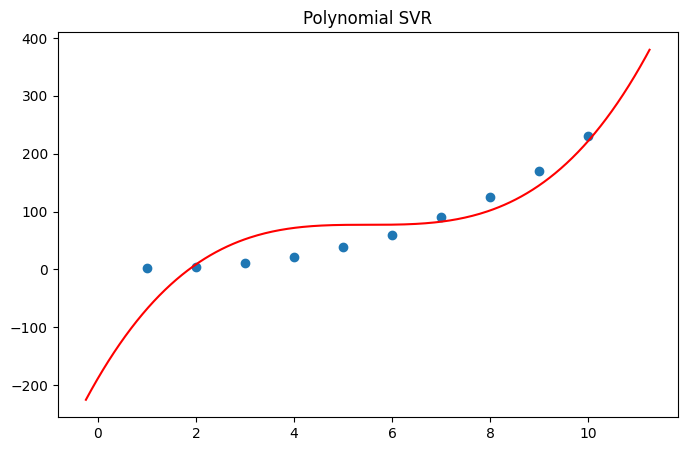

In [140]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

X=np.array([[1],[2],[3],[4],[5],[6],[7],[8],[9],[10]])
y=np.array([2,5,12,22,38,60,90,125,170,230])

sx=StandardScaler()
sy=StandardScaler()

X=sx.fit_transform(X)
y=sy.fit_transform(y.reshape(-1,1)).ravel()

model=SVR(kernel="poly",degree=3,C=100)

model.fit(X,y)

grid=np.linspace(-2,2,300).reshape(-1,1)

prediction=model.predict(grid)

prediction=sy.inverse_transform(prediction.reshape(-1,1))

plt.figure(figsize=(8,5))
plt.scatter(sx.inverse_transform(X),
            sy.inverse_transform(y.reshape(-1,1)))

plt.plot(sx.inverse_transform(grid),
         prediction,
         color="red")

plt.title("Polynomial SVR")
plt.show()

# Program 5: House Price Prediction

R2 Score: 0.4465117877119059


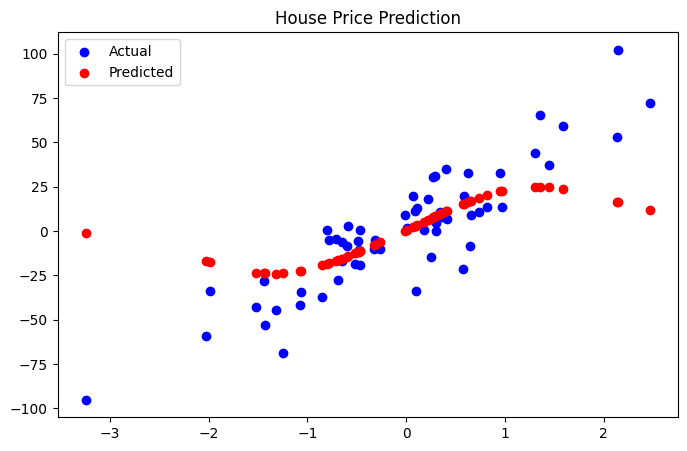

In [141]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import r2_score

X,y=make_regression(
    n_samples=300,
    n_features=1,
    noise=15,
    random_state=42
)

X_train,X_test,y_train,y_test=train_test_split(
X,y,test_size=0.2,random_state=42)

model=SVR(kernel="rbf")

model.fit(X_train,y_train)

prediction=model.predict(X_test)

print("R2 Score:",r2_score(y_test,prediction))

plt.figure(figsize=(8,5))
plt.scatter(X_test,y_test,color="blue",label="Actual")
plt.scatter(X_test,prediction,color="red",label="Predicted")
plt.legend()
plt.title("House Price Prediction")
plt.show()

** 1. Predict a Single New Value**

In [142]:
# Predict for X = 50

new_data = np.array([[50]])

prediction = model.predict(new_data)

print(f"Prediction for X = 50 : {prediction[0]:.2f}")

Prediction for X = 50 : 1.05


In [143]:
new_data = np.array([
    [-100],
    [-50],
    [0],
    [50],
    [100]
])

predictions = model.predict(new_data)

for x, y in zip(new_data, predictions):
    print(f"Input = {x[0]:6.1f} --> Predicted = {y:.2f}")

Input = -100.0 --> Predicted = 1.05
Input =  -50.0 --> Predicted = 1.05
Input =    0.0 --> Predicted = 0.48
Input =   50.0 --> Predicted = 1.05
Input =  100.0 --> Predicted = 1.05
